# Batch Inference

This notebook shows how to run Migas-1.5 on **multiple time series** in a single `predict()` call and how to iterate over a directory of CSV files to collect forecasts.
 
**Requirements:** Install the package (`uv sync`). For live summarization a vLLM server must be running; to skip it, pass `summaries=` (pre-computed summaries are used in the second half of this notebook). See [LLM server setup](../README.md#optional-llm-server) in the README.
 
**Data:** Download prepared FNSPID CSVs and summaries:
```bash
uv run python scripts/download_data.py --dataset fnspid --all
```

In [ ]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from migaseval import MigasPipeline, list_data_files

sys.path.insert(0, "..")
from scripts.plotting_utils import plot_forecast_grid, apply_migas_style

apply_migas_style()

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device=device)
print(f"Using device: {device}")

Loading Chronos-2 on device: cuda:0
Loading TimesFM 2.5...
Downloaded.
Compiling model...
TimesFM 2.5 loaded
Initialized univariate models: chronos, timesfm (prophet on-demand)
Using device: cuda


## Batching multiple samples in one call

`predict()` accepts a batch dimension: `context` has shape `(B, T)` and `text` is a list of B lists. This is more efficient than calling `predict()` in a loop.

In [2]:
csv_dir = "../data/fnspid_prepared/fnspid_0.5_complement_csvs"
csv_files = list_data_files(csv_dir)[:4]  # first 4 datasets
print(f"Using {len(csv_files)} datasets: {[os.path.basename(f) for f in csv_files]}")

seq_len = 384
pred_len = 16

contexts = []
texts = []
names = []

for path in csv_files:
    df = pd.read_csv(path)
    df = df.head(seq_len)
    contexts.append(df["y_t"].values.astype(np.float32))
    texts.append(df["text"].fillna("").astype(str).tolist())
    names.append(os.path.splitext(os.path.basename(path))[0])

context_batch = np.stack(contexts)  # (B, seq_len)
print(f"Batch context shape: {context_batch.shape}")

Using 4 datasets: ['abbv_with_text.csv', 'abt_with_text.csv', 'adbe_with_text.csv', 'amat_with_text.csv']
Batch context shape: (4, 384)


In [3]:
forecast_batch = pipeline.predict(context_batch, texts, pred_len=pred_len)
print(f"Batch forecast shape: {forecast_batch.shape}")  # (B, pred_len, 1)

Batch forecast shape: torch.Size([4, 16, 1])


## Plotting batch results

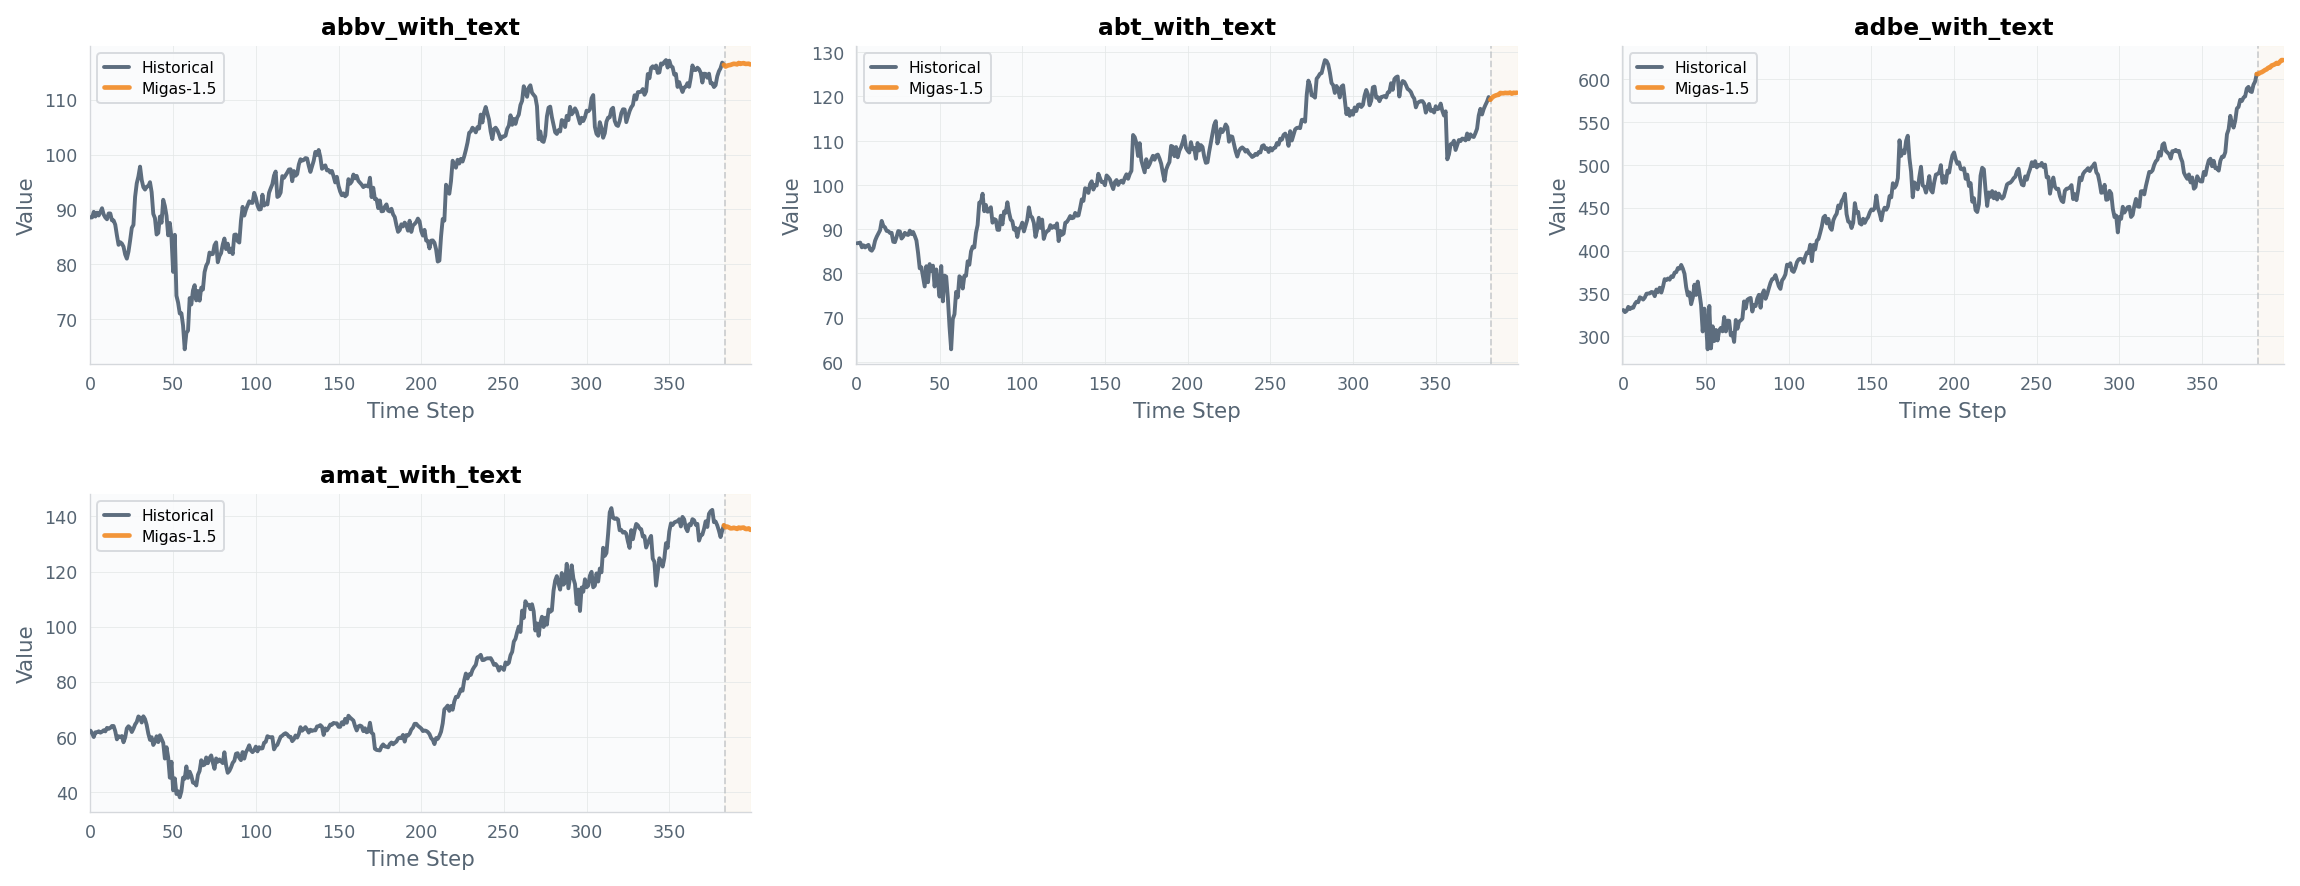

In [4]:
context_len = context_batch.shape[1]
history_2d = context_batch
preds_2d = {"Migas-1.5": forecast_batch[:, :, 0].detach().cpu().numpy()}
fig, axes = plot_forecast_grid(history_2d, None, preds_2d, context_len, pred_len, list(range(len(names))), titles=names)
plt.show()

## Iterating over a directory with pre-computed summaries

For large-scale runs you'll typically loop over files and collect results. Using pre-computed summaries avoids the LLM bottleneck.

In [5]:
csv_dir = "../data/fnspid_prepared/fnspid_0.5_complement_csvs"
summaries_root = "../data/fnspid_prepared/fnspid_0.5_complement"

results = []

for csv_path in list_data_files(csv_dir)[:8]:
    name = os.path.splitext(os.path.basename(csv_path))[0]
    summary_path = os.path.join(summaries_root, name, "summary_0.json")

    if not os.path.exists(summary_path):
        print(f"  Skipping {name} (no summary found)")
        continue

    df = pd.read_csv(csv_path)
    with open(summary_path) as f:
        summary = json.load(f)["summary"]

    forecast = pipeline.predict_from_dataframe(
        df, pred_len=pred_len, seq_len=seq_len, summaries=[summary]
    )
    results.append({"dataset": name, "forecast": forecast.tolist()})
    print(f"  {name}: forecast={forecast[:3]}...")

print(f"\nCollected forecasts for {len(results)} datasets.")

  abbv_with_text: forecast=[154.17072 154.3821  154.52939]...
  abt_with_text: forecast=[107.044586 107.14723  107.1535  ]...
  adbe_with_text: forecast=[589.0952  590.1828  591.47076]...
  amat_with_text: forecast=[160.70903 161.12149 161.02234]...
  Skipping amd_with_text (no summary found)
  Skipping biib_with_text (no summary found)
  Skipping bntx_with_text (no summary found)
  Skipping cmcsa_with_text (no summary found)

Collected forecasts for 4 datasets.


## Collecting results into a DataFrame

In [6]:
rows = []
for r in results:
    for step, val in enumerate(r["forecast"]):
        rows.append({"dataset": r["dataset"], "step": step, "forecast": val})

results_df = pd.DataFrame(rows)
print(results_df.head(20))

# Optionally save
# results_df.to_csv("forecasts.csv", index=False)

           dataset  step    forecast
0   abbv_with_text     0  154.170715
1   abbv_with_text     1  154.382095
2   abbv_with_text     2  154.529388
3   abbv_with_text     3  154.632965
4   abbv_with_text     4  154.672806
5   abbv_with_text     5  154.870605
6   abbv_with_text     6  154.848877
7   abbv_with_text     7  154.850662
8   abbv_with_text     8  154.806641
9   abbv_with_text     9  154.922455
10  abbv_with_text    10  154.898804
11  abbv_with_text    11  155.061203
12  abbv_with_text    12  154.915039
13  abbv_with_text    13  154.964096
14  abbv_with_text    14  155.009186
15  abbv_with_text    15  154.950027
16   abt_with_text     0  107.044586
17   abt_with_text     1  107.147232
18   abt_with_text     2  107.153503
19   abt_with_text     3  107.227921
